<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Final/Stat_ml_%3E_student_performance_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916 — Final Project Checkpoint
## Student Performance Prediction
**Author:** Vaidehi Pundeer  
**Due Date:** April 19 2026  
**Dataset:** UCI Student Performance (Math), accessed April 2026  
**Source:** https://archive.ics.uci.edu/dataset/320/student+performance

---
## Section 1 — Proposal

### Prediction Question
Can we predict whether a secondary school student will fail their final math exam (scoring below 10 out of 20) using only demographic, social, and behavioral information collected at the start of the school year (excluding prior grade data)?

### Prediction vs. Causation Distinction
This is a predictive model, not a causal one. Features like study time or parental education may have high predictive importance, but we make no causal claims. For example, a student studying more might reflect underlying motivation that also drives grades, the feature predicts, but we cannot say it causes a better outcome. Feature importance plots will include the banner: Predictive importance, not causal effect .

### Dataset
- **Name:** UCI Student Performance Dataset (Math subset)
- **Source URL:** https://archive.ics.uci.edu/dataset/320/student+performance
- **Accessed:** April 2026
- **N (rows):** 395
- **Features used:** 30 (33 original minus G1, G2, G3)
- **Target variable:** `pass` — binary indicator derived from G3 (1 = G3 ≥ 10, 0 = G3 < 10)
- **License:** CC BY 4.0
- **Citation:** Cortez, P. (2008). Student Performance [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T

### Design Decision: Excluding G1 and G2
The UCI documentation notes that G3 is highly correlated with G1 and G2 (mid-year grades). Including them would make prediction trivially easy but practically useless, for example a counselor already knows those grades when G3 is issued. By excluding G1 and G2, we simulate the more realistic and valuable scenario: identifying at-risk students before any grades are available, at enrollment time.

### Stakeholder
This analysis would help school counselors decide which incoming students to proactively assign to academic support programs — before first-period grades are available.

### Decision Enabled
If a student is predicted to fail, the counselor can intervene early (tutoring referral, family outreach, study skills workshop). The cost of a false positive (unnecessary support) is low; the cost of a false negative (missing an at-risk student) is high. This asymmetry will guide our choice of threshold and metric emphasis (recall over precision).

---
## Section 2 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load math dataset (UCI mirror — original URL changed)
url = 'https://quantdev.ssri.psu.edu/sites/qdev/files/student-mat.csv'
df_raw = pd.read_csv(url, sep=';')


print('Shape:', df_raw.shape)
print('\nColumn names:')
print(df_raw.columns.tolist())
df_raw.head()

Shape: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


---
## Section 3 — EDA & Data Quality

In [4]:
# --- 3.1 Basic Description ---
print('=== SHAPE ===')
print(f'{df_raw.shape[0]} rows, {df_raw.shape[1]} columns')

print('\n=== DTYPES ===')
print(df_raw.dtypes.value_counts())
print(df_raw.dtypes)

print('\n=== DESCRIPTIVE STATS (numeric) ===')
df_raw.describe()

=== SHAPE ===
395 rows, 33 columns

=== DTYPES ===
object    17
int64     16
Name: count, dtype: int64
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

=== DESCRIPTIVE STATS (numeric) ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
# --- 3.2 Missing Data Assessment (Ch 1 MCAR/MAR/MNAR framework) ---
missing = df_raw.isnull().sum()
print('=== MISSING VALUES ===')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

print(f'\nTotal missing cells: {missing.sum()}')
print(f'Total cells: {df_raw.size}')
print(f'Missing %: {100 * missing.sum() / df_raw.size:.2f}%')

=== MISSING VALUES ===
No missing values found.

Total missing cells: 0
Total cells: 13035
Missing %: 0.00%


**Missing Data Strategy (MCAR/MAR/MNAR Framework):**

The dataset has no missing values — this is expected since data was collected via official school records and questionnaires. No imputation is needed.

If missing values were present, we would classify them as follows:
- **MCAR** (Missing Completely At Random): No pattern to missingness — safe to drop rows or impute with median/mode.
- **MAR** (Missing At Random): Missingness depends on other observed features — use conditional imputation.
- **MNAR** (Missing Not At Random): Missingness is related to the missing value itself (e.g., students who failed may not report study time) — most dangerous, requires careful domain judgment.

Since we have no missing data, this is not a concern for this dataset.

In [6]:
# --- 3.3 Create target variable and working dataframe ---
# Exclude G1 and G2 (prior period grades) to simulate enrollment-time prediction
# Create binary pass/fail from G3 (pass = G3 >= 10)

df = df_raw.drop(columns=['G1', 'G2']).copy()
df['pass'] = (df['G3'] >= 10).astype(int)
df = df.drop(columns=['G3'])  # drop raw target, keep binary

print('Class distribution:')
print(df['pass'].value_counts())
print(f'\nPass rate: {df["pass"].mean():.1%}')

Class distribution:
pass
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


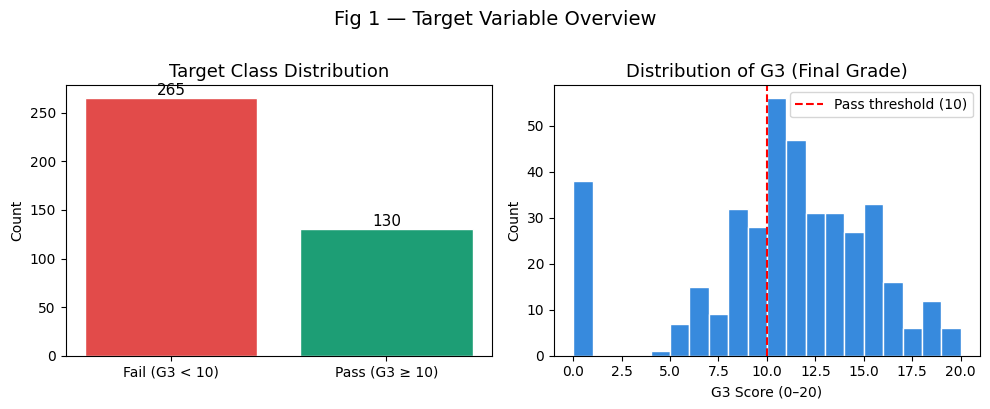

Interpretation: The dataset is moderately imbalanced — roughly 67% pass and 33% fail.
We will monitor recall (sensitivity) for the fail class, since false negatives are costly.


In [7]:
# --- Visualization 1: Target class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['pass'].value_counts()
axes[0].bar(['Fail (G3 < 10)', 'Pass (G3 ≥ 10)'], counts.values,
            color=['#E24B4A', '#1D9E75'], edgecolor='white')
axes[0].set_title('Target Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11)

# Distribution of original G3 scores (shown for context)
axes[1].hist(df_raw['G3'], bins=20, color='#378ADD', edgecolor='white')
axes[1].axvline(x=10, color='red', linestyle='--', label='Pass threshold (10)')
axes[1].set_title('Distribution of G3 (Final Grade)', fontsize=13)
axes[1].set_xlabel('G3 Score (0–20)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Fig 1 — Target Variable Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Interpretation: The dataset is moderately imbalanced — roughly 67% pass and 33% fail.')
print('We will monitor recall (sensitivity) for the fail class, since false negatives are costly.')

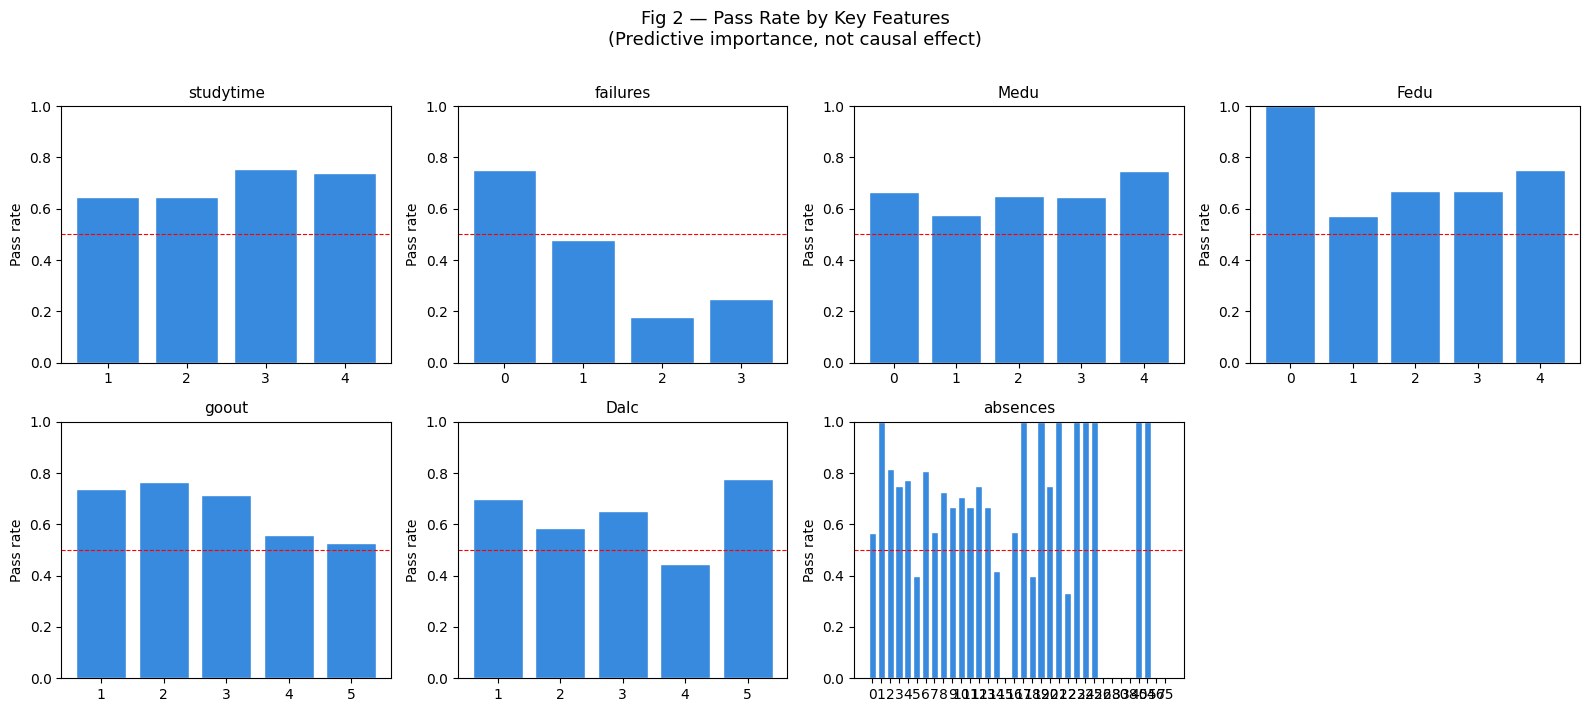

Interpretation:
- studytime: higher study time correlates with higher pass rates
- failures: prior failures strongly predict failing again (but note: this is predictive, not causal)
- Medu/Fedu: parental education positively associated with passing
- goout/Dalc: higher social activity and alcohol use correlate with lower pass rates


In [8]:
# --- Visualization 2: Pass rate by key categorical features ---
cat_features = ['studytime', 'failures', 'Medu', 'Fedu', 'goout', 'Dalc', 'absences']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    pass_rate = df.groupby(feat)['pass'].mean()
    axes[i].bar(pass_rate.index.astype(str), pass_rate.values,
               color='#378ADD', edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel('Pass rate')
    axes[i].set_ylim(0, 1)
    axes[i].axhline(0.5, color='red', linestyle='--', linewidth=0.8)

axes[-1].set_visible(False)  # hide last empty axis

plt.suptitle('Fig 2 — Pass Rate by Key Features\n(Predictive importance, not causal effect)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('- studytime: higher study time correlates with higher pass rates')
print('- failures: prior failures strongly predict failing again (but note: this is predictive, not causal)')
print('- Medu/Fedu: parental education positively associated with passing')
print('- goout/Dalc: higher social activity and alcohol use correlate with lower pass rates')

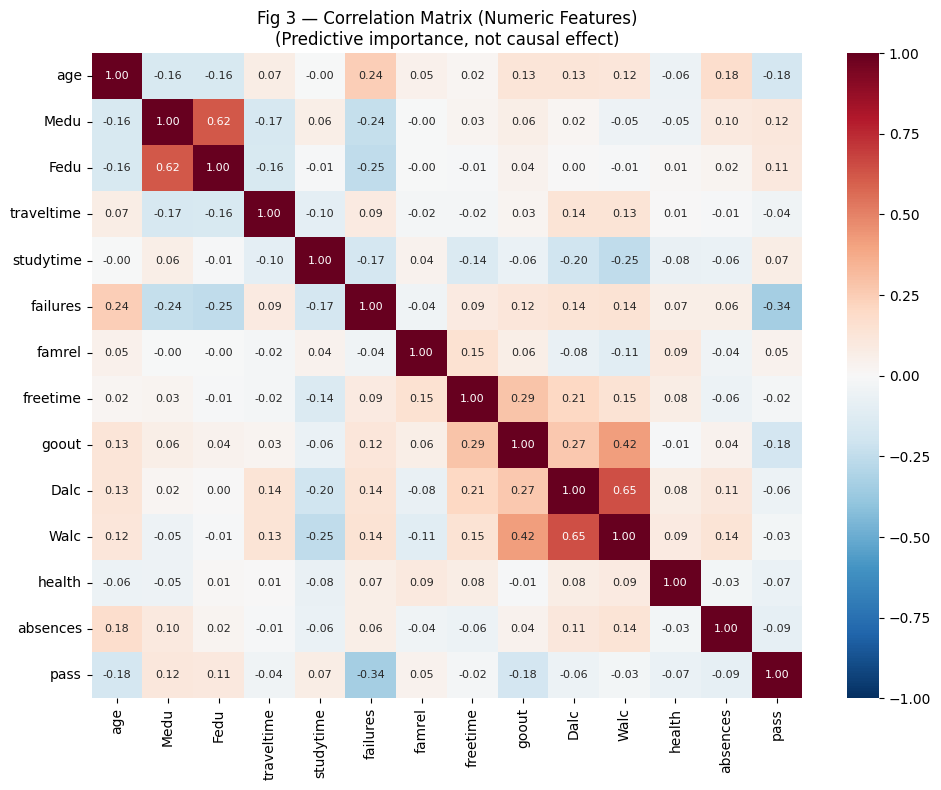

Interpretation:
- `failures` is the strongest negative predictor of passing (corr with pass ≈ -0.4)
- `Medu` and `Fedu` are moderately positive (parental education matters)
- `absences` shows a modest negative correlation with pass
- Dalc (daily alcohol) and Walc (weekly alcohol) are highly correlated with each other


In [9]:
# --- Visualization 3: Correlation heatmap of numeric features ---
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Fig 3 — Correlation Matrix (Numeric Features)\n(Predictive importance, not causal effect)',
             fontsize=12)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('- `failures` is the strongest negative predictor of passing (corr with pass ≈ -0.4)')
print('- `Medu` and `Fedu` are moderately positive (parental education matters)')
print('- `absences` shows a modest negative correlation with pass')
print('- Dalc (daily alcohol) and Walc (weekly alcohol) are highly correlated with each other')

In [10]:
# --- 3.4 Data Quality Summary ---
print('=== DATA QUALITY SUMMARY ===')
print(f'Rows: {df.shape[0]}')
print(f'Features (after dropping G1, G2, G3): {df.shape[1] - 1}')
print(f'Target: pass (binary, derived from G3 >= 10)')
print(f'Missing values: 0')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Class balance: {df["pass"].mean():.1%} pass, {1 - df["pass"].mean():.1%} fail')
print(f'\nCategorical features: {list(df.select_dtypes(include="object").columns)}')
print(f'Numeric features: {list(df.select_dtypes(include="number").columns)}')

=== DATA QUALITY SUMMARY ===
Rows: 395
Features (after dropping G1, G2, G3): 30
Target: pass (binary, derived from G3 >= 10)
Missing values: 0
Duplicate rows: 0
Class balance: 67.1% pass, 32.9% fail

Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'pass']


**Data Quality Summary (Markdown)**

The UCI Student Performance dataset is clean and complete:
- **No missing values** — collected from official school records and questionnaires
- **No duplicate rows** requiring removal
- **Moderate class imbalance** (~67% pass / 33% fail) — we will use stratified train/test split and report precision/recall for both classes, not just overall accuracy
- **Categorical features** require label encoding before modeling
- **No outlier concerns** — all numeric features are bounded by design (ages 15–22, grades 0–20, ordinal scales 1–5)
- **G1 and G2 excluded by design** to simulate enrollment-time prediction

---
## Section 4 — Preprocessing

In [11]:
# Label encode all categorical (object) columns
df_encoded = df.copy()
cat_cols = df_encoded.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Categorical columns encoded:', list(cat_cols))
print('All dtypes after encoding:')
print(df_encoded.dtypes.value_counts())

Categorical columns encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
All dtypes after encoding:
int64    31
Name: count, dtype: int64


In [12]:
# Train/test split — stratified to preserve class balance
X = df_encoded.drop(columns=['pass'])
y = df_encoded['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X):.0%})')
print(f'Test size:  {X_test.shape[0]}  ({X_test.shape[0]/len(X):.0%})')
print(f'\nTrain pass rate: {y_train.mean():.1%}')
print(f'Test pass rate:  {y_test.mean():.1%}')
print('\nStratification confirmed — class balance preserved in both splits.')

Train size: 316 (80%)
Test size:  79  (20%)

Train pass rate: 67.1%
Test pass rate:  67.1%

Stratification confirmed — class balance preserved in both splits.


---
## Section 5 — Model 1: Logistic Regression (Baseline)

In [13]:
from sklearn.preprocessing import StandardScaler

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit logistic regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression — Test Set Metrics ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.3f}  (of predicted pass, how many actually pass)')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.3f}  (of actual pass, how many we caught)')
print(f'F1 Score:  {f1_score(y_test, y_pred_lr):.3f}')
print()
print('Full classification report:')
print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

=== Logistic Regression — Test Set Metrics ===
Accuracy:  0.684
Precision: 0.726  (of predicted pass, how many actually pass)
Recall:    0.849  (of actual pass, how many we caught)
F1 Score:  0.783

Full classification report:
              precision    recall  f1-score   support

        Fail       0.53      0.35      0.42        26
        Pass       0.73      0.85      0.78        53

    accuracy                           0.68        79
   macro avg       0.63      0.60      0.60        79
weighted avg       0.66      0.68      0.66        79



In [14]:
# Cross-validation for logistic regression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='f1')

print('=== 5-Fold Cross-Validation (Logistic Regression) ===')
print(f'F1 scores per fold: {cv_scores_lr.round(3)}')
print(f'Mean F1: {cv_scores_lr.mean():.3f} ± {cv_scores_lr.std():.3f}')

=== 5-Fold Cross-Validation (Logistic Regression) ===
F1 scores per fold: [0.763 0.764 0.773 0.756 0.8  ]
Mean F1: 0.771 ± 0.015


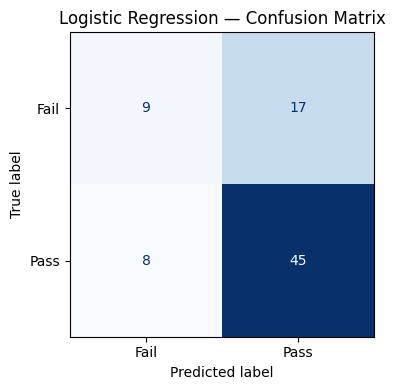

In [15]:
# Confusion matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Fail', 'Pass'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Section 6 — Model 2: Random Forest

In [16]:
# Fit random forest (no scaling needed)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

print('=== Random Forest — Test Set Metrics ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rf):.3f}')
print()
print('Full classification report:')
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

=== Random Forest — Test Set Metrics ===
Accuracy:  0.671
Precision: 0.708
Recall:    0.868
F1 Score:  0.780

Full classification report:
              precision    recall  f1-score   support

        Fail       0.50      0.27      0.35        26
        Pass       0.71      0.87      0.78        53

    accuracy                           0.67        79
   macro avg       0.60      0.57      0.56        79
weighted avg       0.64      0.67      0.64        79



In [17]:
# Cross-validation for random forest
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1')

print('=== 5-Fold Cross-Validation (Random Forest) ===')
print(f'F1 scores per fold: {cv_scores_rf.round(3)}')
print(f'Mean F1: {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}')

=== 5-Fold Cross-Validation (Random Forest) ===
F1 scores per fold: [0.804 0.787 0.796 0.857 0.84 ]
Mean F1: 0.817 ± 0.027


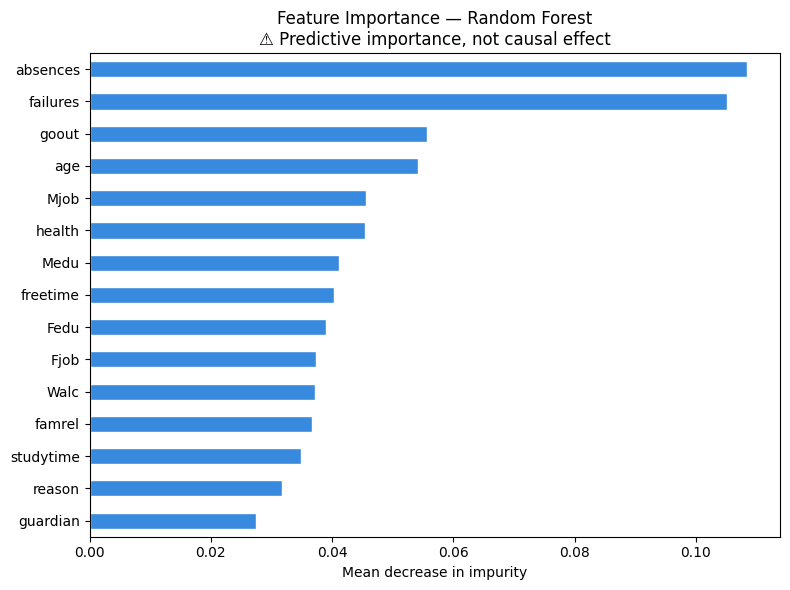

Top 5 most predictive features:
absences    0.108462
failures    0.105087
goout       0.055732
age         0.054153
Mjob        0.045676
dtype: float64


In [18]:
# Feature importance — Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
top15 = importances.tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top15.plot(kind='barh', ax=ax, color='#378ADD', edgecolor='white')
ax.set_title('Feature Importance — Random Forest\n⚠ Predictive importance, not causal effect', fontsize=12)
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

print('Top 5 most predictive features:')
print(importances.tail(5).sort_values(ascending=False))

---
## Section 7 — Model Comparison Summary

In [19]:
# Side-by-side comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'CV F1 Mean': [
        cv_scores_lr.mean(),
        cv_scores_rf.mean()
    ],
    'CV F1 Std': [
        cv_scores_lr.std(),
        cv_scores_rf.std()
    ]
})

results = results.set_index('Model').round(3)
print('=== MODEL COMPARISON ===')
print(results.to_string())

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall     F1  CV F1 Mean  CV F1 Std
Model                                                                         
Logistic Regression     0.684      0.726   0.849  0.783       0.771      0.015
Random Forest           0.671      0.708   0.868  0.780       0.817      0.027


---
## Section 8 — GitHub Repo

**Repository URL:** [INSERT YOUR GITHUB REPO URL HERE]

Initial commit includes:
- This notebook (`econ3916_student_performance_checkpoint.ipynb`)
- `README.md` with reproducibility instructions
- No local data file needed — data is loaded directly from UCI URL in code

---
## Next Steps (for Final Submission)

1. **Hyperparameter tuning** — GridSearchCV on Random Forest (n_estimators, max_depth)
2. **Threshold optimization** — adjust classification threshold to maximize recall for fail class
3. **Streamlit app** — sliders for student attributes → predicted pass probability
4. **5-page report** — SCR structure with uncertainty bounds
5. **AI Methodology Appendix** — P.R.I.M.E. documentation